# Edit Flows: Discrete Flow Matching with Edit Operations

Here, I replicate the **"Edit Flows: Flow Matching with Edit Operations"** paper by [Havasi et al.](https://arxiv.org/abs/2506.09018) which introduces a non-factorized probability path model for discrete flow matching via insertions, deletions, and substitutions.

#### Import

In [8]:
import sys
from pathlib import Path
from collections import defaultdict
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import clear_output
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchtyping import TensorType as T
from typing import Tuple, cast
import hashlib
from flow import (
    KappaScheduler, CubicScheduler,
    Coupling, EmptyCoupling, GeneratorCoupling, UniformCoupling,
    sample_p, x2prob,
)


#### Dataset Overview

In [ ]:
class FairseqStyleTextDataset(Dataset):
    def __init__(self, src_path, tgt_path, dict_path, add_bos=True, add_eos=True):
        # 1) load dictionary
        SPECIAL_OFFSET = 4     # pad, unk, bos, eos 4개

        self.tok2idx = {}
        self.tok2idx["<pad>"] = 0
        self.tok2idx["<unk>"] = 1
        self.tok2idx["<s>"]   = 2
        self.tok2idx["</s>"]  = 3

        with open(dict_path, 'r', encoding='utf-8') as f:
            for idx, line in enumerate(f):
                if line.strip() == "":
                    continue
                tok = line.split()[0]
                self.tok2idx[tok] = idx + SPECIAL_OFFSET

        self.bos = self.tok2idx.get("<s>", None)
        self.eos = self.tok2idx.get("</s>", None)
        self.unk = self.tok2idx.get("<unk>", None)

        self.add_bos = add_bos
        self.add_eos = add_eos

        # 2) load src/tgt text lines
        with open(src_path, 'r', encoding='utf-8') as f:
            self.src_lines = [line.strip() for line in f]

        with open(tgt_path, 'r', encoding='utf-8') as f:
            self.tgt_lines = [line.strip() for line in f]

        assert len(self.src_lines) == len(self.tgt_lines)

    def encode(self, line):
        # 3) split tokens (BPE tokens already pre-split)
        tokens = line.split()

        # 4) numericalize
        ids = []
        if self.add_bos and self.bos is not None:
            ids.append(self.bos)

        for t in tokens:
            ids.append(self.tok2idx.get(t, self.unk))

        if self.add_eos and self.eos is not None:
            ids.append(self.eos)

        return torch.tensor(ids, dtype=torch.long)

    def __getitem__(self, idx):
        src_ids = self.encode(self.src_lines[idx])
        tgt_ids = self.encode(self.tgt_lines[idx])
        return {
            "id": idx,
            "source": src_ids,
            "target": tgt_ids,
            "src_len": src_ids.size(0),
            "tgt_len": tgt_ids.size(0),
        }

    def __len__(self):
        return len(self.src_lines)

def collate_fn(samples):
    if len(samples) == 0:
        return {}

    src_lengths = torch.tensor([s["src_len"] for s in samples], dtype=torch.long)
    tgt_lengths = torch.tensor([s["tgt_len"] for s in samples], dtype=torch.long)

    max_src = src_lengths.max().item()
    max_tgt = tgt_lengths.max().item()

    pad_idx = 1  # fairseq default: 1 = <pad>

    bs = len(samples)
    src_batch = torch.full((bs, max_src), pad_idx, dtype=torch.long)
    tgt_batch = torch.full((bs, max_tgt), pad_idx, dtype=torch.long)

    for i, s in enumerate(samples):
        src = s["source"]
        tgt = s["target"]
        src_batch[i, : src.size(0)] = src
        tgt_batch[i, : tgt.size(0)] = tgt

    return {
        "id": torch.tensor([s["id"] for s in samples]),
        "net_input": {
            "src_tokens": src_batch,
            "src_lengths": src_lengths,
        },
        "target": tgt_batch,
    }

dataset = FairseqStyleTextDataset(
    "./datasets/USPTO_50K/aug20/train.src",
    "./datasets/USPTO_50K/aug20/train.tgt",
    "./datasets/USPTO_50K/dict.txt",
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn,
)


In [ ]:
def make_sinusoidal_sequence(
    L: int,
    noise: float,
    num_cycles_fn=lambda: np.random.uniform(1.5, 3.5),
    x_int_fn=lambda: np.random.uniform(0, 2*np.pi),
) -> np.ndarray:
    """Generate y = 0.5 * sin(B(x - C)) + 0.5 with optional Gaussian noise."""

    x = np.linspace(0, 4*np.pi, L)                  # [L]
    cycles = num_cycles_fn()
    B = cycles / 2                                  # frequency
    C = x_int_fn()
    y = 0.5 * np.sin(B * (x - C)) + 0.5             # [L]
    if noise > 0:
        y += np.random.normal(0, noise, L)          # [L]
    return y                                        # [L]

def plot_sequences(xs, title="Sequences", pad_token=None):
    plt.figure(figsize=(8,4)); plt.title(title); plt.xlabel("Index"); plt.ylabel("Value"); plt.grid()
    colors = plt.cm.viridis(np.linspace(0,1,len(xs)))
    for i, y in enumerate(xs):
        if pad_token is not None: y = y[y != pad_token]
        plt.scatter(range(len(y)), y, s=10, c=[colors[i]])
    plt.tight_layout(); plt.show()


#### Training Edit Flow Models



#### Model

In [ ]:
# Helper functions

BOS_TOKEN = 128
PAD_TOKEN = 129
GAP_TOKEN = 130

def _align_pair(seq0: torch.Tensor, seq1: torch.Tensor):
    """Return two aligned sequences using minimum-edit dynamic programming."""
    
    seq0 = seq0.cpu().numpy()
    seq1 = seq1.cpu().numpy()
    m, n = len(seq0), len(seq1)
    
    # DP table
    dp = [[i + j for j in range(n + 1)] for i in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if seq0[i-1] == seq1[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])   # delete, insert, substitute

    # Backtracking
    aligned_0, aligned_1 = [], []
    i, j = m, n
    while i > 0 or j > 0:
        # Case 1: match / substitute (prefer match)
        if i > 0 and j > 0 and dp[i][j] == dp[i-1][j-1] + (seq0[i-1] != seq1[j-1]):
            aligned_0.append(seq0[i-1])
            aligned_1.append(seq1[j-1])
            i -= 1
            j -= 1
            continue
        # Case 2: delete (seq0 element unmatched)
        if i > 0 and dp[i][j] == dp[i-1][j] + 1:
            aligned_0.append(seq0[i-1])
            aligned_1.append(GAP_TOKEN)
            i -= 1
            continue
        # Case 3: insert (seq1 element unmatched)
        aligned_0.append(GAP_TOKEN)
        aligned_1.append(seq1[j-1])
        j -= 1

    return aligned_0[::-1], aligned_1[::-1]

def opt_align_xs_to_zs(x_0: torch.Tensor, x_1: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Aligns x_0 and x_1 to the same length by using a dynamic programming approach
    to find the minimum edit distance alignment.
    """
    aligned_pairs = [_align_pair(x_0[b], x_1[b]) for b in range(x_0.shape[0])]
    x_0_aligned = torch.stack(
        [torch.tensor(pair[0], dtype=x_0.dtype, device=x_0.device) for pair in aligned_pairs])
    x_1_aligned = torch.stack(
        [torch.tensor(pair[1], dtype=x_1.dtype, device=x_1.device) for pair in aligned_pairs])
    return x_0_aligned, x_1_aligned

# --------
def sample_cond_pt(p0: torch.Tensor, p1: torch.Tensor, t: torch.Tensor, kappa: KappaScheduler):
    t = t.reshape(-1, 1, 1)
    pt = (1 - kappa(t)) * p0 + kappa(t) * p1
    return sample_p(pt)

def make_x0_like_x1(
    x1: torch.Tensor,
    vocab_size: int = 128,
    pad_token: int = PAD_TOKEN,
    noise: float = 0.05,
    **kwargs,
) -> torch.Tensor:
    batch_size, x1_max_len = x1.shape
    x0s = []
    for i in range(batch_size):
        x1i_len = (x1[i] != pad_token).sum().item()
        x0i = torch.Tensor(make_sinusoidal_sequence(int(x1i_len), noise=noise, **kwargs))
        x0i = torch.round(torch.clip(x0i * vocab_size, min=0.0, max=vocab_size-1)).long()
        x0i = F.pad(x0i, (0, x1_max_len - x0i.shape[0]), value=pad_token)
        x0s.append(x0i)
    x0s = torch.stack(x0s, dim=0).long()  # (batch_size, x1_max_len)
    assert x0s.shape == x1.shape, "x0 and x1 must have the same shape"
    return x0s

def make_x0_with_bounds(
    batch_size: int = 2,
    min_length: int = 96,
    max_length: int = 96,
    vocab_size: int = 128,
    pad_token: int = PAD_TOKEN,
    noise: float = 0.05,
    **kwargs
) -> torch.Tensor:
    
    lengths = np.random.randint(min_length, max_length+1, size=(batch_size,))
    max_seq_len = lengths.max()
    x0s = []
    for length in lengths:
        x0i = torch.Tensor(make_sinusoidal_sequence(length, noise=noise, **kwargs))
        x0i = torch.round(torch.clip(x0i * vocab_size, min=0.0, max=vocab_size-1)).long()
        x0i = F.pad(x0i, (0, max_seq_len - x0i.shape[0]), value=pad_token)
        x0s.append(x0i)
    x0s = torch.stack(x0s, dim=0).long()  # (batch_size, max_seq_len)
    assert x0s.shape[1] == max_seq_len
    assert x0s.shape[0] == batch_size
    return x0s

def make_batch(
    batch_size: int = 2,
    min_length: int = 96,
    max_length: int = 96,
    vocab_size: int = 128,
    pad_token: int = PAD_TOKEN,
    bos_token: int = BOS_TOKEN,
    coupling: Coupling = EmptyCoupling(),
    seq_align_fn = opt_align_xs_to_zs,
    noise: float = 0.05,
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    **kwargs,
):

    # 1) Random lengths
    lengths = np.random.randint(min_length, max_length + 1, size=batch_size)

    x0_list, x1_list, z0_list, z1_list = [], [], [], []

    # 2) Generate sequences + coupling + alignment
    for L in lengths:
        s = make_sinusoidal_sequence(L, noise=noise, **kwargs)

        # x1: Create directly on GPU
        x1 = torch.from_numpy(
            np.clip(np.round(s * vocab_size), 0, vocab_size - 1)
        ).long().to(device).unsqueeze(0)     # [1, L]

        # coupling.sample returns same device as input
        x0, _ = coupling.sample(x1)          # [1, L0], must already be GPU

        # alignment: can output CPU or GPU, so normalize it
        z0, z1 = seq_align_fn(x0, x1)

        # z0, z1 may be list/np/tensor → unify to tensor on same device
        z0 = torch.as_tensor(z0, dtype=torch.long, device=device).view(-1)
        z1 = torch.as_tensor(z1, dtype=torch.long, device=device).view(-1)

        x1_list.append(x1.squeeze(0))
        x0_list.append(x0.squeeze(0))
        z0_list.append(z0)
        z1_list.append(z1)

    # 3) compute max lengths
    x0_max = max(len(x) for x in x0_list)
    x1_max = max(len(x) for x in x1_list)
    z_max  = max(len(z) for z in z1_list)
    assert z_max == max(len(z) for z in z0_list)

    # 4) pad helper
    def pad_stack(seq_list, max_len):
        return torch.stack(
            [F.pad(s, (0, max_len - s.size(0)), value=pad_token) for s in seq_list],
            dim=0
        ).long().to(device)

    x0 = pad_stack(x0_list, x0_max)
    x1 = pad_stack(x1_list, x1_max)
    z0 = pad_stack(z0_list, z_max)
    z1 = pad_stack(z1_list, z_max)

    # 5) BOS prepend (GPU-safe)
    def add_bos(x):
        return F.pad(x, (1, 0), value=bos_token)

    x0 = add_bos(x0)
    x1 = add_bos(x1)
    z0 = add_bos(z0)
    z1 = add_bos(z1)

    # 6) time step + mask
    t = torch.rand(batch_size, 1, device=device)
    pad_mask = (x1 == pad_token)

    return x0, x1, z0, z1, t, pad_mask

def make_ut_mask_from_z(
    z_t: T["batch_size", "z_seq_len", "long"],
    z_1: T["batch_size", "z_seq_len", "long"],
    vocab_size: int = 130,
    pad_token: int = PAD_TOKEN,
    gap_token: int = GAP_TOKEN,
) -> T["batch_size", "z_seq_len", "n_ops", "bool"]:
    
    """
    Create a mask for u_cat for indexing the output rate tensor based on differences between z_t and z_1.
    For each position i where z_t and z_1 differ, we index as follows:

    - z_t[i] = GAP_TOKEN & z_1[i] = c => u_mask[i, insert, c] = 1
    - z_t[i] = c & z_1[i] = GAP_TOKEN => u_mask[i, delete] = 1
    - z_t[i] = c1 & z_1[i] = c2 => u_mask[i, substitute, c1, c2] = 1
    """
    batch_size, z_seq_len = z_t.shape
    n_ops = 2 * vocab_size + 1  # insert + substitute + delete

    z_neq = (z_t != z_1) & (z_t != pad_token) & (z_1 != pad_token)
    z_ins = (z_t == gap_token) & (z_1 != gap_token) & z_neq         # (batch_size, z_seq_len)
    z_del = (z_t != gap_token) & (z_1 == gap_token) & z_neq         # (batch_size, z_seq_len)
    z_sub = z_neq & ~z_ins & ~z_del                                 # (batch_size, z_seq_len) 

    # mask (batch_size, z_seq_len, u_ops) where 1 indicates operation that bring z_t closer to z_1
    u_mask = torch.zeros((batch_size, z_seq_len, n_ops), dtype=torch.bool, device=z_t.device)
    u_mask[z_ins, z_1[z_ins]] = True
    u_mask[z_sub, z_1[z_sub] + vocab_size] = True
    u_mask[:,:,-1][z_del] = True

    assert z_neq.sum() == (z_ins | z_del | z_sub).sum(), "Mismatch in number of edits"
    assert z_neq.sum() == u_mask.sum(), "Mismatch in number of edits in mask"

    return cast(T["batch_size", "z_seq_len", "n_ops", "bool"], u_mask)

def fill_gap_tokens_with_repeats(
    x_ut: torch.Tensor,
    z_gap_mask: torch.Tensor,
    z_pad_mask: torch.Tensor,
):
    batch_size, _ = z_gap_mask.shape
    _, x_seq_len, _ = x_ut.shape

    # Use cumsum on non-gap positions to point to the last valid non-gap position
    non_gap_mask = ~z_gap_mask  # Invert mask to get non-gap positions
    indices = non_gap_mask.cumsum(dim=1) - 1        # (batch_size, z_seq_len)
    indices = indices.clamp(min=0, max=x_seq_len-1) # Ensure indices are within bounds

    # Use indices to gather from x_ut
    batch_indices = torch.arange(batch_size, device=x_ut.device).unsqueeze(1)
    result = x_ut[batch_indices, indices]   # (batch_size, z_seq_len, vocab_size)
    result[z_pad_mask] = 0                  # Set pad positions to 0
    return result


In [4]:
def rm_gap_tokens(z: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Remove gap tokens from a batched tensor and right-pad with PAD_TOKEN.
    """    
    batch_size, _ = z.shape
    z_no_gap = []
    for b in range(batch_size):
        z_no_pad = z[b][z[b] != PAD_TOKEN]
        z_no_gap.append(z_no_pad[z_no_pad != GAP_TOKEN])
    max_len = max(len(z) for z in z_no_gap)
    x = torch.stack([F.pad(z, (0, max_len - len(z)), value=PAD_TOKEN) for z in z_no_gap], dim=0).long()
    x_pad_mask = (x == PAD_TOKEN)
    z_gap_mask = (z == GAP_TOKEN)
    z_pad_mask = (z == PAD_TOKEN)
    assert ((~x_pad_mask).sum(1) + z_gap_mask.sum(1)).equal((~z_pad_mask).sum(1))
    return x, x_pad_mask, z_gap_mask, z_pad_mask

def safe_chr(c: int, show_special_chars=False, compact=False) -> str:
    if c == GAP_TOKEN:
        return 'Δ' if compact else '<GAP>'
    elif c == PAD_TOKEN:
        return 'π' if compact else '<PAD>'
    elif c == BOS_TOKEN:
        return '<BOS>'
    try:
        ch = chr(c)
        # Replace non-printable or whitespace (except space) with '.'
        if ch.isprintable() and (ch == ' ' or not ch.isspace()):
            return ch
        elif show_special_chars:
            return repr(ch)
        else:
            return '.'
    except Exception:
        return '.'

def pretty_parse(x: torch.Tensor, **kwargs) -> str:
    x_str = ''.join(safe_chr(int(c), **kwargs) for c in x.cpu().numpy().flatten())
    return x_str

def pretty_print(x: torch.Tensor, **kwargs) -> None:
    """
    Pretty print a tensor as an ascii string with gap tokens represented as '-'
    Non-printable/special characters (including line breaks, tabs, etc.) are replaced with '.'
    """
    print(pretty_parse(x, **kwargs))

In [5]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.H = hidden_dim
        half = hidden_dim // 2
        inv_freq = torch.exp(-torch.arange(half, dtype=torch.float32) * (math.log(10000) / (half - 1)))
        self.register_buffer("inv_freq", inv_freq)  # [H/2]

    def forward(self, t: torch.Tensor) -> torch.Tensor:  # t: [B,1]
        if t.dim() == 1:
            t = t.unsqueeze(1)  # [B,1]

        x = t.float() * self.inv_freq.unsqueeze(0)      # [B, H/2]
        emb = torch.cat([torch.sin(x), torch.cos(x)], dim=-1)  # [B, H or H-1]
        if self.H % 2 == 1:
            emb = torch.nn.functional.pad(emb, (0, 1))         # [B, H]
        return emb  # [B, H]


class SimpleEditFlowsTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        hidden_dim: int,
        num_layers: int,
        num_heads=8,
        max_seq_len=512,
        bos_token_id=128,
        pad_token_id=129,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.max_seq_len = max_seq_len
        self.bos_token_id = bos_token_id
        self.pad_token_id = pad_token_id

        self.H = hidden_dim
        self.V = vocab_size
        self.pad_id = pad_token_id

        assert bos_token_id < vocab_size
        assert pad_token_id < vocab_size

        # Embeddings
        self.token_emb = nn.Embedding(vocab_size, hidden_dim)
        self.pos_emb = nn.Embedding(max_seq_len, hidden_dim)
        self.time_emb = nn.Sequential(
            SinusoidalTimeEmbedding(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # Transformer
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=hidden_dim,
                nhead=num_heads,
                dim_feedforward=hidden_dim * 4,
                dropout=0.1,
                activation="gelu",
                batch_first=False,
            )
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(hidden_dim)

        # Projection heads
        self.rates_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 3),
        )
        self.ins_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.sub_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.1)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)

    def forward(
        self,
        tokens: T["B","L","long"],
        t: T["B",1,"float"],
        pad_mask: T["B","L","bool"],
    ):
        B, L = tokens.shape
       
        # --- Embeddings ---
        tok = self.token_emb(tokens)                 # [B,L,H]
        tim = self.time_emb(t).unsqueeze(1).expand(B, L, -1)  # [B,L,H]
        pos = self.pos_emb(torch.arange(L, device=tokens.device))  # [L,H]
        pos = pos.unsqueeze(0).expand(B, L, -1)      # [B,L,H]

        x = tok + tim + pos                          # [B,L,H]
        
        # --- Transformer ---
        x = x.transpose(0, 1)                        # [L,B,H]
        for layer in self.layers:
            x = layer(x, src_key_padding_mask=pad_mask)
        x = x.transpose(0, 1)                        # [B,L,H]
        x = self.norm(x)                             # [B,L,H]

        # --- Edit rate output ---
        rates = F.softplus(self.rates_head(x))       # [B,L,3]
        rates = torch.clamp(rates, max=50.0)         # stability

        # --- Insert / Substitute token projections ---
        ins_h = self.ins_head(x)                     # [B,L,H]
        sub_h = self.sub_head(x)                     # [B,L,H]
        V_emb = self.token_emb.weight                # [V,H]
        ins_logits = (ins_h @ V_emb.T) / math.sqrt(self.H)  # [B,L,V]
        sub_logits = (sub_h @ V_emb.T) / math.sqrt(self.H)  # [B,L,V]
        ins_logits = torch.clamp(ins_logits, -50, 50)   # stability
        sub_logits = torch.clamp(sub_logits, -50, 50)   # stability
        
        # mask padded positions: -inf
        pad_inf = pad_mask.unsqueeze(-1)
        ins_logits = ins_logits.masked_fill(pad_inf, -1e9)
        sub_logits = sub_logits.masked_fill(pad_inf, -1e9)
        # probs
        ins = F.softmax(ins_logits, dim=-1)          # [B,L,V]
        sub = F.softmax(sub_logits, dim=-1)          # [B,L,V]
        
        # zero out padded positions
        valid = (~pad_mask).unsqueeze(-1).float()    # [B,L,1]
        rates = rates * valid                        # [B,L,3]
        ins = ins * valid                            # [B,L,V]
        sub = sub * valid                            # [B,L,V]

        # minimal NaN check (core only)
        if torch.isnan(x).any():
            raise ValueError("NaN in transformer output")

        return rates, ins, sub


### Training Objective

$$ \mathcal{L}(\theta) = \mathbb{E}_{t, p_t(x_t, z_t \mid z_0, z_1)}^{\pi(z_0, z_1)} \Bigg[\sum_{x \neq x_t} u_t^{\theta}(x \mid x_t) - \sum_{i=1}^{N} \mathbf{1}[z_1^{i} \neq z_t^{i}] \frac{\dot{\kappa}_t}{1 - \kappa_t} \log u_t^{\theta}\big(x(z_t, i, z_1^{i}) \mid x_t\big) \Bigg] $$


In [6]:
# Training loop

torch.manual_seed(42)
np.random.seed(42)

metrics = defaultdict(list)

# Constants
V = 128
L = 128
batch_size = 128
min_seq_len, max_seq_len = 64, 128

# Functions
seq_align_fn = opt_align_xs_to_zs
num_cycles_fn = lambda: np.random.uniform(2.5, 4)
x_int_fn = lambda: np.random.uniform(0, 2 * np.pi)

generator_fn = lambda x1: make_x0_with_bounds(
    batch_size=int(x1.shape[0]),
    min_length=min_seq_len,
    max_length=max_seq_len,
    vocab_size=V,
    pad_token=PAD_TOKEN,
    num_cycles_fn=lambda: np.random.uniform(1., 2.5),
    x_int_fn=x_int_fn,
)

# Choose coupling
# coupling = EmptyCoupling()
coupling = GeneratorCoupling(generator_fn)
# coupling = UniformCoupling(min_len=min_seq_len, max_len=max_seq_len, mirror_len=True, vocab_size=V, pad_token=PAD_TOKEN)

scheduler = CubicScheduler(a=1.0, b=1.0)
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print(device)

# Model
model = SimpleEditFlowsTransformer(
    vocab_size=V + 2,     # PAD + BOS
    hidden_dim=512,
    num_layers=8,
    num_heads=32,
    max_seq_len=2 * L,
    pad_token_id=V,
    bos_token_id=V + 1,
).to(device)
model.train()

optim = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training Loop
steps = 384000 // batch_size
pbar = tqdm(range(steps), desc="Training Edit Flows", unit="step")

for step in pbar:
    # 1) Sample batch & interpolate in Z space
    x0, x1, z0, z1, t, _ = make_batch(
        batch_size=batch_size,
        min_length=min_seq_len,
        max_length=max_seq_len,
        vocab_size=V,
        coupling=coupling,
        seq_align_fn=seq_align_fn,
        num_cycles_fn=num_cycles_fn,
        x_int_fn=x_int_fn,
    )

    zt = sample_cond_pt(
        x2prob(z0, V + 3),
        x2prob(z1, V + 3),
        t,
        scheduler,
    )
    # Remove gaps, pad, and get masks
    xt, x_mask, z_gap_mask, z_pad_mask = rm_gap_tokens(zt)
    assert (~x_mask).sum(1).max().item() == xt.shape[1]

    # 2) Compute uz_mask (which operations move z_t → z_1)  (B, ZL, 2V+1)
    uz_mask = make_ut_mask_from_z(
        zt, z1,  # [B,ZL]: int 
        vocab_size=V + 2,  # +2 for PAD and BOS tokens
    )

    # 3) Model forward
    ut, ins_p, sub_p = model(
        tokens=xt.to(device),
        t=t.to(device),
        pad_mask=x_mask.to(device),
    )
    λ_ins = ut[:, :, 0]       # Insertion rate        [B,L]
    λ_sub = ut[:, :, 1]       # Substitution rate     [B,L]
    λ_del = ut[:, :, 2]       # Deletion rate         [B,L]

    # Invariants
    assert ut[x_mask].sum() == 0
    assert ins_p[x_mask].sum() == 0
    assert sub_p[x_mask].sum() == 0
    assert sub_p[~x_mask].sum(-1).allclose(torch.ones_like(sub_p[~x_mask].sum(-1)))
    assert ins_p[~x_mask].sum(-1).allclose(torch.ones_like(ins_p[~x_mask].sum(-1)))
    assert not uz_mask[z_pad_mask].any()

    # 4) Construct local edit rates u_t(i, a)
    u_ins = λ_ins.unsqueeze(-1) * ins_p  # BLV
    u_sub = λ_sub.unsqueeze(-1) * sub_p  # BLV
    u_del = λ_del.unsqueeze(-1)          # BL1

    ux_cat = torch.cat([u_ins, u_sub, u_del], dim=-1)                      # B,L,2V+1
    uz_cat = fill_gap_tokens_with_repeats(ux_cat, z_gap_mask, z_pad_mask)  # B,L,2V+1
    u_tot = ut.sum(dim=(1, 2))                                             # B,

    # Numeric checks
    if torch.isnan(ux_cat).any():
        raise ValueError("NaN in ux_cat")
    if torch.isnan(uz_cat).any():
        raise ValueError("NaN in uz_cat")

    assert uz_cat.shape[1] == zt.shape[1]
    assert uz_cat.shape[1] >= ux_cat.shape[1]
    assert ux_cat[x_mask].sum() == 0
    assert uz_cat[z_pad_mask].sum() == 0
    assert (uz_cat < 0).sum() == 0

    # 5) Loss = Bregman divergence
    sched_coeff = (scheduler.derivative(t) / (1 - scheduler(t))).to(device)    

    eps = 1e-8
    safe_u = uz_cat.clamp(min=eps)
    log_u = torch.log(safe_u).clamp(min=-20)

    loss = u_tot - (log_u * uz_mask.to(device) * sched_coeff.unsqueeze(-1)).sum(dim=(1, 2))
    loss = loss.mean()

    assert not torch.isnan(loss)
    assert not torch.isinf(loss)

    optim.zero_grad()
    loss.backward()
    optim.step()

    metrics["loss"].append(loss.item())
    metrics["u_tot"].append(u_tot.mean().item())
    metrics["u_ins"].append(λ_ins.sum(dim=1).mean().item())
    metrics["u_del"].append(λ_del.sum(dim=1).mean().item())
    metrics["u_sub"].append(λ_sub.sum(dim=1).mean().item())
    metrics["u_con"].append((uz_cat * uz_mask.to(device)).sum(dim=(1, 2)).mean().item())

    if step % 10 == 0:
        # clear_output(wait=True)  # Clear previous output
        print(
            f"Step {step}: Loss={loss.item():.4f}, "
            f"u_tot={u_tot.mean().item():.4f}, "
            f"u_ins={metrics['u_ins'][-1]:.4f}, "
            f"u_del={metrics['u_del'][-1]:.4f}, "
            f"u_sub={metrics['u_sub'][-1]:.4f}, "
            f"u_con={metrics['u_con'][-1]:.4f}"
        )
        sys.stdout.flush()


cuda


Training Edit Flows:   0%|          | 0/3000 [00:00<?, ?step/s]

Step 0: Loss=664.7514, u_tot=202.6532, u_ins=67.5492, u_del=67.6323, u_sub=67.4717, u_con=4.4296


Training Edit Flows:   0%|          | 10/3000 [00:06<27:46,  1.79step/s] 

Step 10: Loss=647.0117, u_tot=164.8962, u_ins=43.1416, u_del=46.7617, u_sub=74.9930, u_con=2.6476


...

Training Edit Flows:  99%|█████████▉| 2980/3000 [26:58<00:10,  1.86step/s]

Step 2980: Loss=577.8871, u_tot=101.2474, u_ins=10.8287, u_del=11.1785, u_sub=79.2403, u_con=1.0047


Training Edit Flows: 100%|█████████▉| 2990/3000 [27:04<00:05,  1.83step/s]

Step 2990: Loss=606.9529, u_tot=102.8796, u_ins=12.0909, u_del=11.8153, u_sub=78.9734, u_con=0.9696


Training Edit Flows: 100%|██████████| 3000/3000 [27:09<00:00,  1.84step/s]


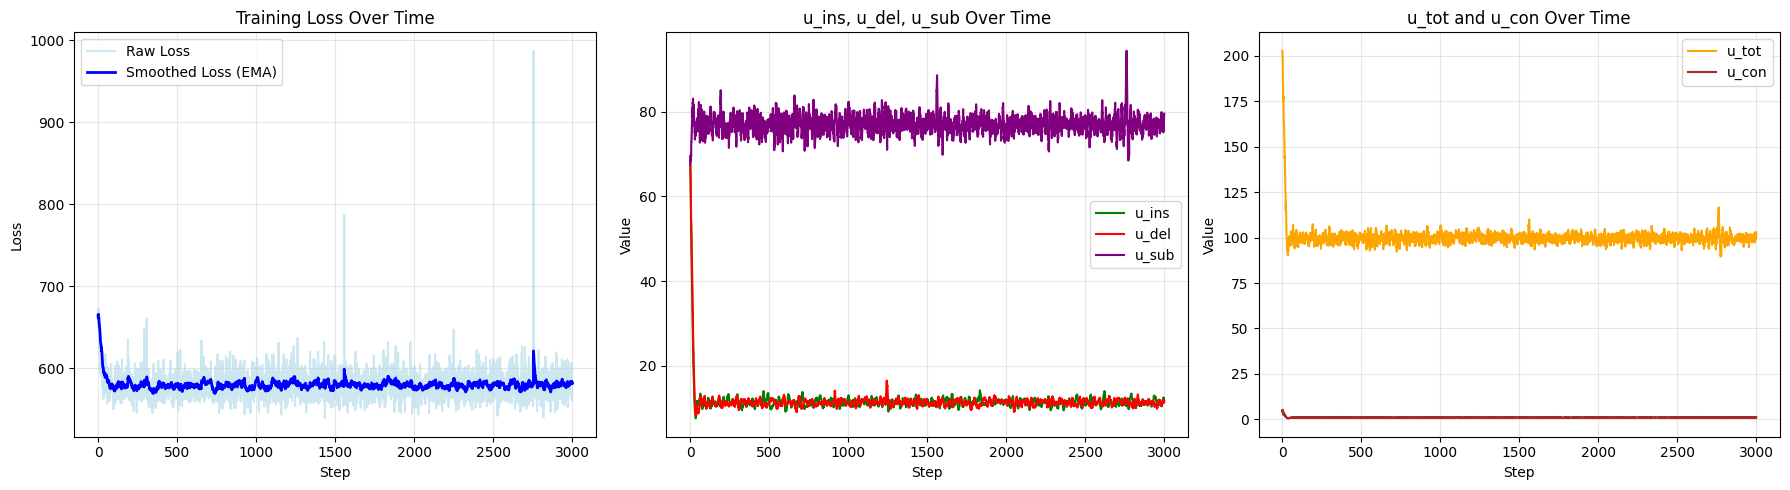

In [9]:
# Visualize the training metrics

# 1 row, 3 columns
plt.figure(figsize=(18, 5))

# 1. Plot loss (raw and smoothed)
plt.subplot(1, 3, 1)
plt.plot(metrics["loss"], label='Raw Loss', color='lightblue', alpha=0.6)
smoothed_losses = pd.Series(metrics["loss"]).ewm(alpha=0.1).mean()
plt.plot(smoothed_losses, label='Smoothed Loss (EMA)', color='blue', linewidth=2)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3); plt.legend()

# 2. Plot u_ins, u_del, u_sub
plt.subplot(1, 3, 2)
plt.plot(metrics["u_ins"], label='u_ins', color='green')
plt.plot(metrics["u_del"], label='u_del', color='red')
plt.plot(metrics["u_sub"], label='u_sub', color='purple')
plt.xlabel('Step'); plt.ylabel('Value'); plt.title('u_ins, u_del, u_sub Over Time')
plt.grid(True, alpha=0.3); plt.legend()

# 3. Plot u_tot and u_con
plt.subplot(1, 3, 3)
plt.plot(metrics["u_tot"], label='u_tot', color='orange')
plt.plot(metrics["u_con"], label='u_con', color='brown')
plt.xlabel('Step')
plt.ylabel('Value')
plt.title('u_tot and u_con Over Time')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Sampling via First Order Euler Step


In [10]:
# Helper functions for sampling the model

def apply_ins_del_operations(
    x_t: T["batch_size", "seq_len", "long"],
    ins_mask: T["batch_size", "seq_len", "bool"],
    del_mask: T["batch_size", "seq_len", "bool"],
    ins_tokens: T["batch_size", "seq_len", "long"],
    max_seq_len: int = 512,
    pad_token=GAP_TOKEN,
) -> T["batch_size", "max_new_len", "long"]:
    """
    Apply insertion and deletion operations to a sequence x_t based on the provided masks.
    """
    batch_size, seq_len = x_t.shape
    device = x_t.device

    # Handle simultaneous ins+del as substitutions
    replace_mask = ins_mask & del_mask
    x_t_modified = x_t.clone()
    x_t_modified[replace_mask] = ins_tokens[replace_mask]

    # Update ins/del masks after handling replacements
    eff_ins_mask = ins_mask & ~replace_mask
    eff_del_mask = del_mask & ~replace_mask

    # Compute new lengths after applying ins/del operations
    xt_pad_mask = (x_t == pad_token)  # (batch_size, seq_len)
    xt_seq_lens = (~xt_pad_mask).sum(dim=1)  # (batch_size,)
    new_lengths = xt_seq_lens + eff_ins_mask.sum(dim=1) - eff_del_mask.sum(dim=1)
    max_new_len = int(new_lengths.max().item())

    if max_new_len <= 0:
        print(f"Unexpected max_new_len <= 0: {max_new_len}, did we delete everything?")
        return cast(
            T["batch_size", "max_new_len", "long"],
            torch.full((batch_size, 1), pad_token, dtype=x_t.dtype, device=device),
        )

    # Pre-allocate result
    x_new = torch.full((batch_size, max_new_len), pad_token, dtype=x_t.dtype, device=device)

    # Compute positions
    batch_idx = torch.arange(batch_size, device=device).unsqueeze(1)    # (batch_size, 1)
    pos_idx = torch.arange(seq_len, device=device).unsqueeze(0)         # (1, seq_len)
    cum_del = torch.cumsum(eff_del_mask.float(), dim=1)                 # num del up to & incl. current pos
    cum_ins = torch.cumsum(eff_ins_mask.float(), dim=1)                 # num ins up to & incl. current pos
    cum_ins_before = F.pad(cum_ins[:, :-1], (1, 0), value=0)            # num ins before current pos
    
    # Place non-deleted tokens
    new_pos = pos_idx + cum_ins_before - cum_del                            # new pos of tokens shifted by ins/del
    keep_mask = ~eff_del_mask & (new_pos >= 0) & (new_pos < max_new_len)    # tokens to keep (non-deleted)
    if keep_mask.any():
        x_new[batch_idx.expand(-1, seq_len)[keep_mask], new_pos[keep_mask].long()] = x_t_modified[keep_mask]

    # Place insertions
    if eff_ins_mask.any():
        ins_pos = new_pos + 1                                               # insertions go 1 after new shifted pos
        ins_valid = eff_ins_mask & (ins_pos >= 0) & (ins_pos < max_new_len) # tokens to insert
        if ins_valid.any():
            x_new[batch_idx.expand(-1, seq_len)[ins_valid], ins_pos[ins_valid].long()] = ins_tokens[ins_valid]
    
    if max_new_len > max_seq_len:
        print(f"Warning: max_new_len {max_new_len} exceeds max_seq_len {max_seq_len}, truncating.")
        max_new_len = max_seq_len
    
    return cast(
        T["batch_size", "max_new_len", "long"],
        x_new[:, :max_new_len],
    )

def get_adaptive_h(h: float, t: torch.Tensor, scheduler: KappaScheduler):
    coeff = (1 - scheduler(t)) / scheduler.derivative(t)
    _h = h * torch.ones_like(t, device=t.device)
    h_adapt = torch.minimum(_h, coeff)
    return h_adapt

def load_model_state(model_name: str):
    checkpoint = torch.load(model_name, map_location=device)
    model = SimpleEditFlowsTransformer(
        vocab_size=checkpoint['vocab_size'],
        hidden_dim=checkpoint['hidden_dim'],
        num_layers=checkpoint['num_layers'],
        num_heads=checkpoint['num_heads'],
        max_seq_len=checkpoint['max_seq_len'],
        bos_token_id=checkpoint['bos_token_id'],
        pad_token_id=checkpoint['pad_token_id'],
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    optim = torch.optim.Adam(model.parameters(), lr=0.0001)
    optim.load_state_dict(checkpoint['optimizer_state_dict'])
    return model.to(device), optim

In [11]:
# (Optional) Save / Load the model state
save_model = True
load_model = False
overwrite = True

save_dir = Path(f"results/target_shift")
model_name = Path(f"seq2seq_prior.pt")

if save_model:
    save_path = save_dir / model_name
    if not overwrite:
        assert not save_path.exists(), f"Model file {save_path} already exists. Please choose a different name."
    assert save_path.parent.exists(), f"Directory {save_path.parent} does not exist. Please create it first."
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optim.state_dict(),
        'vocab_size': model.V,
        'hidden_dim': model.H,
        # 'num_layers': model.num_layers,  #####
        # 'num_heads': model.num_heads,
        # 'max_seq_len': model.max_seq_len,
        # 'bos_token_id': model.bos_token_id,
        # 'pad_token_id': model.pad_token_id,
    }, save_path)
    print(f"Model saved to {save_path}")

if load_model:
    save_path = save_dir / model_name
    assert save_path.exists(), f"Model file {save_path} does not exist."
    model, optim = load_model_state(save_path)
    print(f"Model loaded from {save_path}")

Model saved to results/target_shift/seq2seq_prior.pt


In [13]:
# Sampling loop

n_steps = 1000
n_samples = 4
t_min = 0.0

model.eval()

default_h = 1 / n_steps
t = t_min * torch.ones(n_samples, 1)

# Sample initial x_t = x_0 from the coupling
x_0, _, _, _, _, _ = make_batch(
    batch_size=n_samples,
    min_length=64,  ##min_seq_len,
    max_length=128,  ##max_seq_len,
    vocab_size=V,
    coupling=coupling,
    seq_align_fn=seq_align_fn,
    num_cycles_fn=num_cycles_fn,
    x_int_fn=x_int_fn,
)

x_t = x_0.clone()
x_pad_mask = (x_t == PAD_TOKEN) # Create padding mask for x_t
x_ts = [x_t.clone()]

with tqdm(desc="Euler Sampling") as pbar:
    while t.max() <= 1 - default_h:
        u_t, ins_probs, sub_probs = model.forward(
            cast(T["batch_size", "x_seq_len", "long"], x_t.to(device)),
            cast(T["batch_size", 1, "float"], t.to(device)),
            cast(T["batch_size", "x_seq_len", "bool"], x_pad_mask.to(device)),
        )
        lambda_ins = u_t[:, :, 0].cpu()     # Insertion rate        (n_samples, x_seq_len)
        lambda_sub = u_t[:, :, 1].cpu()     # Substitution rate     (n_samples, x_seq_len)
        lambda_del = u_t[:, :, 2].cpu()     # Deletion rate         (n_samples, x_seq_len)

        adapt_h = get_adaptive_h(default_h, t, scheduler)

        # Sample insertions and deletion/substitutions based on rates
        ins_mask = torch.rand(size=lambda_ins.shape, device=lambda_ins.device) < 1 - torch.exp(-adapt_h * lambda_ins)
        del_sub_mask = torch.rand(size=lambda_sub.shape, device=lambda_sub.device) < 1 - torch.exp(-adapt_h * (lambda_sub + lambda_del))

        # For deletion/substitution, sample based on the relative rates
        prob_del = torch.where(del_sub_mask, lambda_del / (lambda_sub + lambda_del), torch.zeros_like(lambda_del))
        del_mask = torch.bernoulli(prob_del).bool()
        sub_mask = del_sub_mask & ~del_mask
        assert sub_mask.sum() + del_mask.sum() == del_sub_mask.sum()

        # Only sample tokens for non-pad positions, fill pad positions with PAD_TOKEN
        ins_tokens = torch.full(ins_probs.shape[:2], PAD_TOKEN, dtype=torch.long, device=x_t.device)
        sub_tokens = torch.full(sub_probs.shape[:2], PAD_TOKEN, dtype=torch.long, device=x_t.device)
        non_pad_mask = ~x_pad_mask
        if non_pad_mask.any():
            ins_sampled = torch.multinomial(ins_probs[non_pad_mask].cpu(), num_samples=1, replacement=True).squeeze(-1).to(x_t.device)
            sub_sampled = torch.multinomial(sub_probs[non_pad_mask].cpu(), num_samples=1, replacement=True).squeeze(-1).to(x_t.device)
            ins_tokens[non_pad_mask] = ins_sampled
            sub_tokens[non_pad_mask] = sub_sampled

        ins_mask = ins_mask.to(x_t.device)
        del_mask = del_mask.to(x_t.device)
        sub_mask = sub_mask.to(x_t.device)
        x_t = x_t.to(x_t.device)

        # Apply operations based on masks
        x_t[sub_mask] = sub_tokens[sub_mask]
        x_t = apply_ins_del_operations(
            cast(T["batch_size", "seq_len", "long"], x_t),
            cast(T["batch_size", "seq_len", "bool"], ins_mask),
            cast(T["batch_size", "seq_len", "bool"], del_mask),
            cast(T["batch_size", "seq_len", "long"], ins_tokens),
            max_seq_len=256,  #model.max_seq_len,
            pad_token=PAD_TOKEN,
        )
        x_pad_mask = (x_t == PAD_TOKEN)  # Update padding mask after operations

        t = t + adapt_h
        x_ts.append(x_t.clone())
        pbar.update(1)

Euler Sampling: 4it [00:00, 18.12it/s]

Euler Sampling: 1000it [00:37, 26.44it/s]


<BOS>.....!(,6D<X]`drauws.~s~.uzvllY]SQBH2'.................&'+?@4AY[fZiw.}y..|~.xxπππππππππππππππππππππππππππππππππππππππ
%..g.!(r.6O.]`6dGrMaRqs.~s~.[uv{lY~..BH.^......>........v..&' .<A_l\.f.A>....~..xvyπππππππππππππππππππππππππππππππππππππππ

<BOS>.....................!,340?C@UJILXR`hhmjprtu..ntu.z...|u~}|vpuldpaVU[ZKCPDD788.',!..............................πππππ
<BOS>.f}}2......t......H.!S34 #zXU..QX:...$aMN..Ekk.zk..%uoQptdaVU.)Z!CP~.7.fQ.,\......_....WA.o.$....y......πππππππππππππππππ

<BOS>..................."%%1<DIKW`\mfq|v{l...y|w{.tfl_ZXUG;A014!..!......πππππππππππππππππππππππππππππππππππππππππππππππππ
L.^....E..8...."....%%d...hW.\Hm.y3Nv.l.-my.{.tfl`|.UGM.0w1<,!..Ry#..πππππππππππππππππππππππππππππππππππππππππππππππππππππ

<BOS>2'&......................)/9?ALJ^`fpioquz......|xsyhpicVLOO8952$..%..................+4,,/D>RV`_ilf{r.{.zv..t|ronncf`
I.WB'].b_..iji..t.#~..U.....})/!?.Lo^`f_iK).z._F..|..sQh.mcE.LOt9YV.4%Ix..]{......4..[k....{+AE,,>>{Y`_.ilm{./{.zx.ts.~.f_



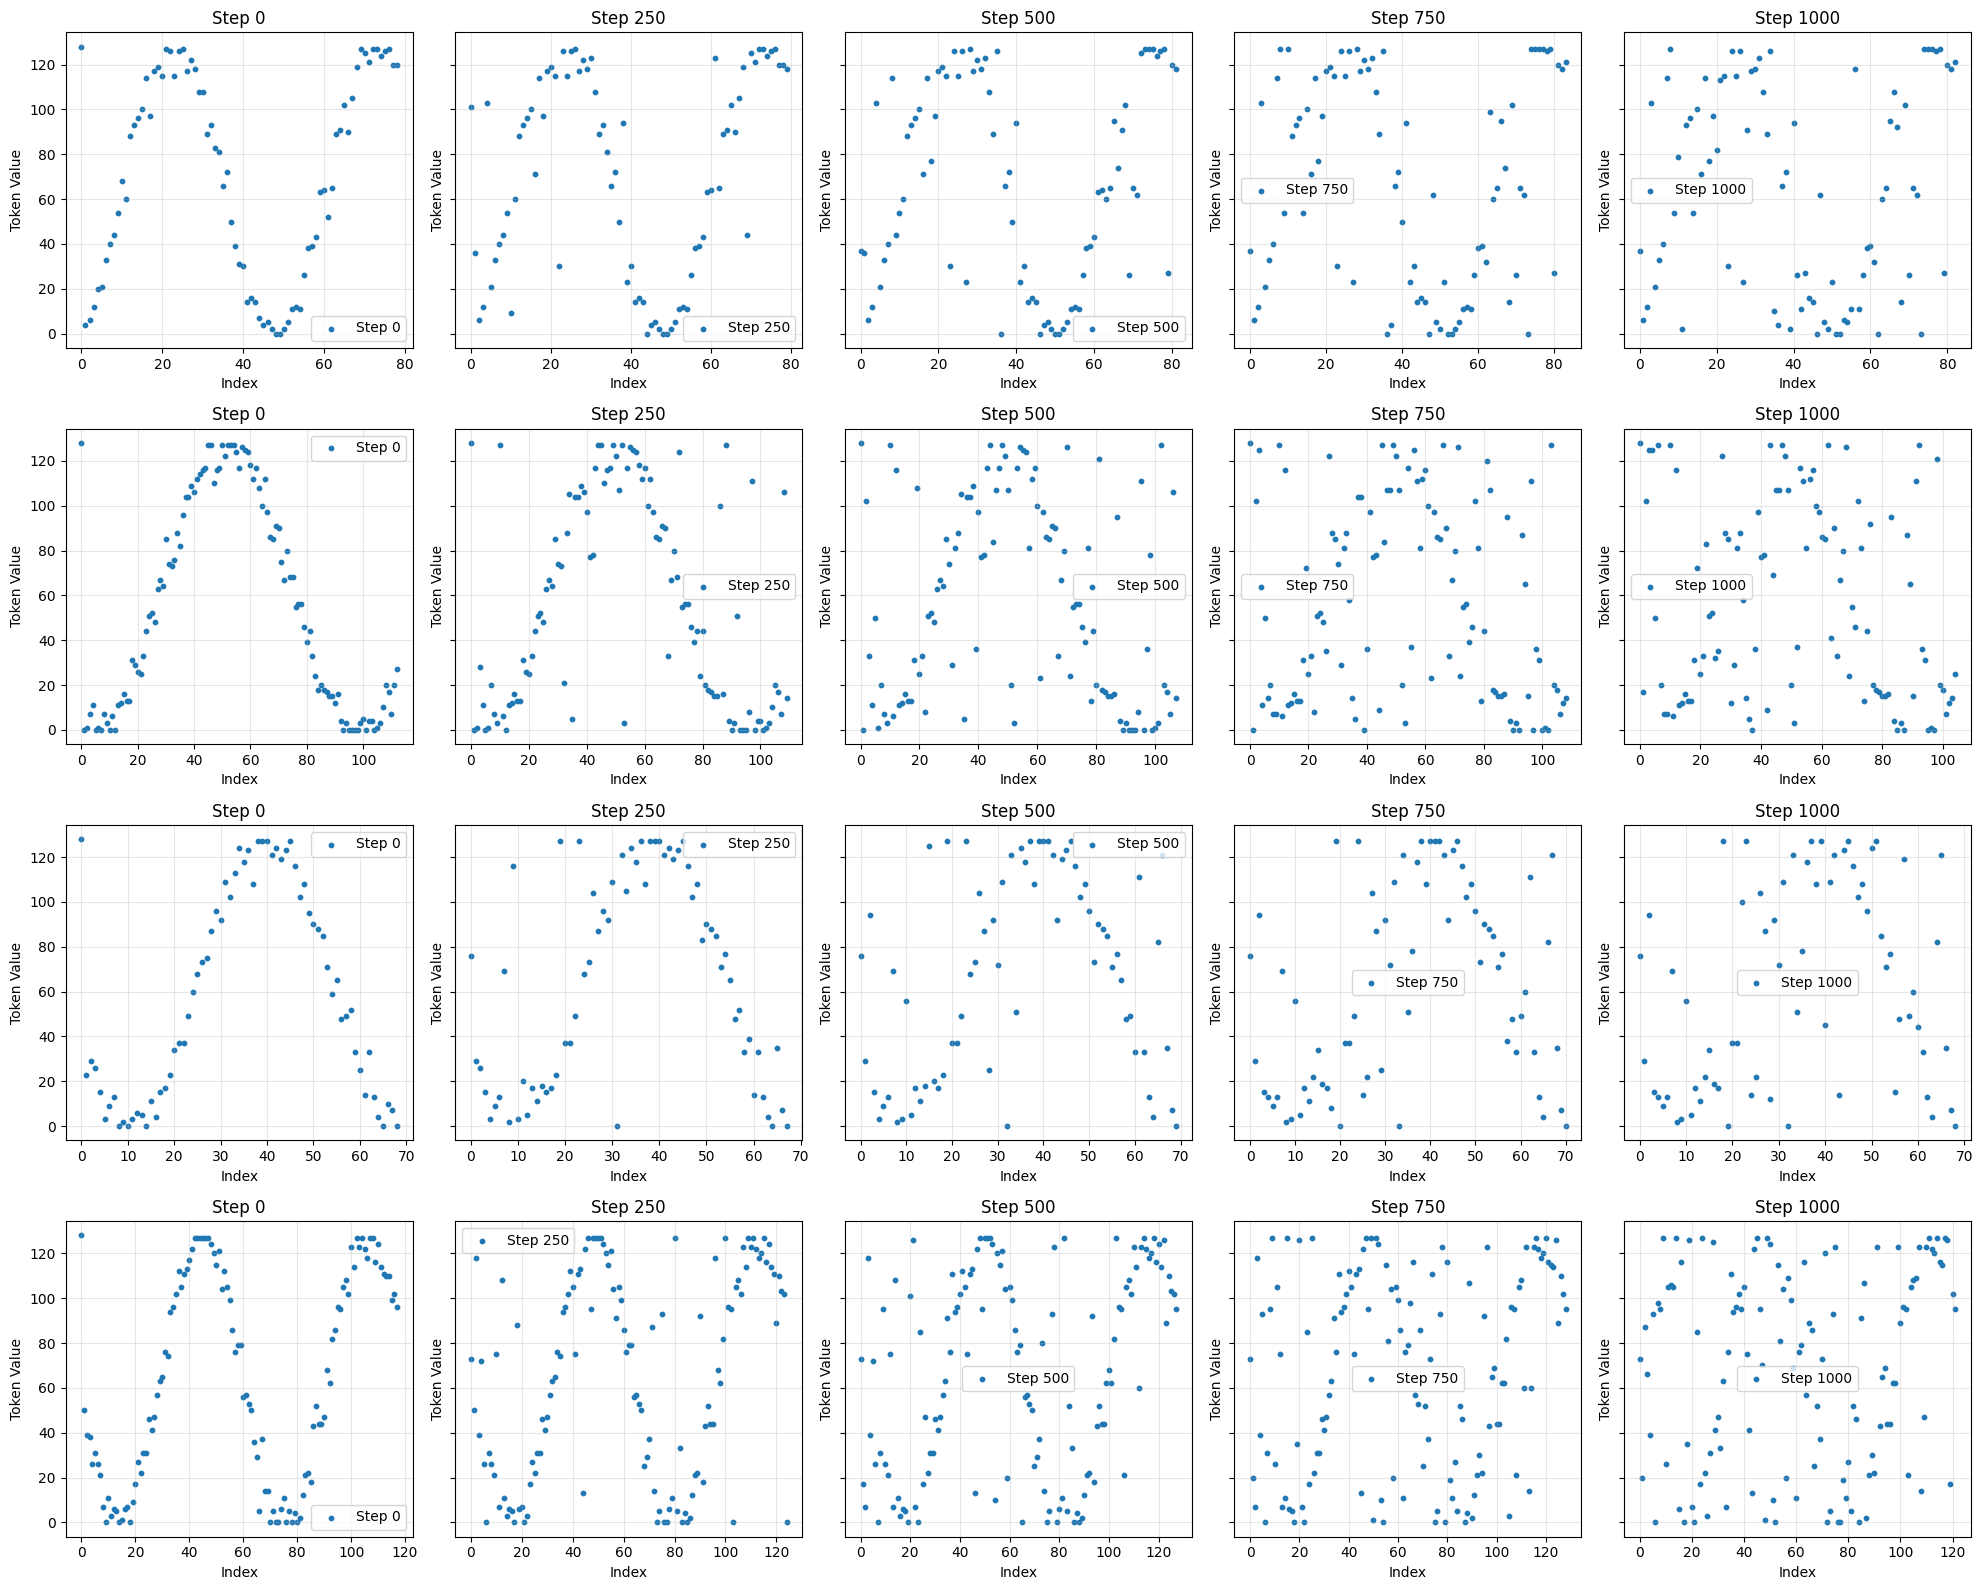

In [14]:
# Visualize the sampled sequences

n_seqs_to_plot = 5
seq_indices = np.linspace(0, len(x_ts) - 1, n_seqs_to_plot, dtype=int)

fig, ax = plt.subplots(n_samples, n_seqs_to_plot, figsize=(20, 4*n_samples), sharey=True)

for j in range(n_samples):
    pretty_print(x_ts[0][j], compact=True)
    pretty_print(x_ts[-1][j], compact=True)
    print()

    seqs = [x_ts[i][j].cpu().numpy().squeeze() for i in seq_indices]

    for i, seq in enumerate(seqs):
        y = seq[seq != PAD_TOKEN]  # Remove padding token
        x = np.arange(len(y))
        ax[j,i].scatter(x, y, label=f"Step {seq_indices[i]}", s=10)
        ax[j,i].set_title(f"Step {seq_indices[i]}")
        ax[j,i].set_xlabel("Index")
        ax[j,i].set_ylabel("Token Value")
        ax[j,i].grid(True, alpha=0.3)
        ax[j,i].legend()

plt.tight_layout()
plt.show()